In [1]:
%load_ext autoreload
%autoreload 2

import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import DiagonalGate, UnitaryGate
from qiskit_aer import StatevectorSimulator


In [2]:
BASIS_GATES = ['rz', 'sx', 'x', 'cx']
simulator   = StatevectorSimulator()

PROJ_0 = np.array([[1, 0], [0, 0]], dtype=complex)
PROJ_1 = np.array([[0, 0], [0, 1]], dtype=complex)


def count_gates(circuit: QuantumCircuit) -> int:
    return sum(1 for instr in circuit.data if instr.operation.name != 'reset')


def time_it(fn, *args, repeats: int = 1, **kwargs):
    """Run `fn` `repeats` times, return (min_seconds, result_of_last_call)."""
    best = float('inf')
    result = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        result = fn(*args, **kwargs)
        dt = time.perf_counter() - t0
        if dt < best:
            best = dt
    return best, result


def build_builtin(base_gate, n_target: int):
    """Approach A: use Qiskit's .control() on the base gate."""
    qc = QuantumCircuit(n_target + 1)
    ancilla   = n_target
    targets   = list(range(n_target))
    qc.append(base_gate.control(ctrl_state='0'), [ancilla] + targets)
    return qc


def build_manual(U: np.ndarray, n_target: int):
    """Approach B: assemble the full controlled matrix, wrap in a single UnitaryGate.

    Mirrors `collision_nonuniform` in qlbm.physics for the SVD path.
    """
    identity   = np.eye(U.shape[0], dtype=complex)
    controlled = np.kron(U, PROJ_0) + np.kron(identity, PROJ_1)
    qc = QuantumCircuit(n_target + 1)
    ancilla   = n_target
    targets   = list(range(n_target))
    qc.append(UnitaryGate(controlled), [ancilla] + targets)
    return qc


def measure(base_gate, U: np.ndarray, n_target: int, runtime_repeats: int = 3):
    """Run both approaches once, return a dict of timings/sizes."""
    row = {'n_target_qubits': n_target, 'total_qubits': n_target + 1}

    # --- Approach A: built-in .control() ---
    t_build_a, qc_a      = time_it(build_builtin, base_gate, n_target)
    t_trans_a, trans_a   = time_it(transpile, qc_a, basis_gates=BASIS_GATES)
    t_sim_a_tr           = transpile(qc_a, simulator)
    t_sim_a, _           = time_it(lambda: simulator.run(t_sim_a_tr).result(),
                                    repeats=runtime_repeats)
    row.update({
        'builtin_build_s':   t_build_a,
        'builtin_transp_s':  t_trans_a,
        'builtin_gates':     count_gates(trans_a),
        'builtin_depth':     trans_a.depth(),
        'builtin_def_gates': count_gates(t_sim_a_tr),
        'builtin_def_depth': t_sim_a_tr.depth(),
        'builtin_runtime_s': t_sim_a,
    })
    del qc_a, trans_a, t_sim_a_tr; gc.collect()

    # --- Approach B: manual Kronecker + UnitaryGate ---
    t_build_b, qc_b      = time_it(build_manual, U, n_target)
    t_trans_b, trans_b   = time_it(transpile, qc_b, basis_gates=BASIS_GATES)
    t_sim_b_tr           = transpile(qc_b, simulator)
    t_sim_b, _           = time_it(lambda: simulator.run(t_sim_b_tr).result(),
                                    repeats=runtime_repeats)
    row.update({
        'manual_build_s':    t_build_b,
        'manual_transp_s':   t_trans_b,
        'manual_gates':      count_gates(trans_b),
        'manual_depth':      trans_b.depth(),
        'manual_def_gates':  count_gates(t_sim_b_tr),
        'manual_def_depth':  t_sim_b_tr.depth(),
        'manual_runtime_s':  t_sim_b,
    })
    del qc_b, trans_b, t_sim_b_tr; gc.collect()

    return row


In [3]:
RNG = np.random.default_rng(0)

diag_rows = []
for n_target in [4, 6, 8]:
    phases = np.exp(1j * RNG.uniform(0, 2 * np.pi, size=2**n_target))
    gate = DiagonalGate(list(phases))
    U = np.diag(phases)

    row = measure(gate, U, n_target)
    row['case']  = 'diagonal'
    row['label'] = f'Random phase diagonal n={n_target}'
    diag_rows.append(row)
    print(f"  {row['label']:30s}  builtin: tr={row['builtin_transp_s']:.2f}s gates={row['builtin_gates']:>6,}  manual: tr={row['manual_transp_s']:.2f}s gates={row['manual_gates']:>6,}")


  Random phase diagonal n=4       builtin: tr=0.02s gates=   281  manual: tr=0.01s gates=    66
  Random phase diagonal n=6       builtin: tr=0.03s gates= 1,197  manual: tr=0.06s gates=   258
  Random phase diagonal n=8       builtin: tr=0.33s gates= 4,849  manual: tr=0.55s gates= 1,026


In [4]:
def random_unitary(n_qubits: int, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    size = 2 ** n_qubits
    A = rng.standard_normal((size, size)) + 1j * rng.standard_normal((size, size))
    Q, R = np.linalg.qr(A)
    d = np.diagonal(R)
    ph = d / np.abs(d)
    return Q * ph


unitary_rows = []
for n_target in [4, 6, 8]:
    U = random_unitary(n_target)
    gate = UnitaryGate(U)
    row = measure(gate, U, n_target)
    row['case']  = 'general'
    row['label'] = f'Random unitary n={n_target}'
    unitary_rows.append(row)
    print(f"  {row['label']:30s}  builtin: tr={row['builtin_transp_s']:.2f}s gates={row['builtin_gates']:>6,}  manual: tr={row['manual_transp_s']:.2f}s gates={row['manual_gates']:>6,}")


  Random unitary n=4              builtin: tr=0.01s gates= 1,158  manual: tr=0.01s gates= 1,156
  Random unitary n=6              builtin: tr=0.12s gates=19,208  manual: tr=0.19s gates=19,206
  Random unitary n=8              builtin: tr=2.33s gates=310,280  manual: tr=4.84s gates=310,280


## Results

In [5]:
df = pd.DataFrame(diag_rows + unitary_rows)

df['transp_speedup']   = df['builtin_transp_s']  / df['manual_transp_s']
df['runtime_speedup']  = df['builtin_runtime_s'] / df['manual_runtime_s']
df['gate_ratio']       = df['builtin_gates']     / df['manual_gates']
df['depth_ratio']      = df['builtin_depth']     / df['manual_depth']

cols = [
    'case', 'label', 'n_target_qubits',
    'builtin_gates',    'manual_gates',    'gate_ratio',
    'builtin_depth',    'manual_depth',    'depth_ratio',
    'builtin_def_gates','manual_def_gates',
    'builtin_def_depth','manual_def_depth',
    'builtin_runtime_s','manual_runtime_s','runtime_speedup',
    'builtin_transp_s', 'manual_transp_s', 'transp_speedup',
]
display(df[cols].round(3))


,case,label,n_target_qubits,builtin_gates,manual_gates,gate_ratio,builtin_depth,manual_depth,depth_ratio,builtin_def_gates,manual_def_gates,builtin_def_depth,manual_def_depth,builtin_runtime_s,manual_runtime_s,runtime_speedup,builtin_transp_s,manual_transp_s,transp_speedup
0,diagonal,Random phase diagonal n=4,4,281,66,4.258,206,55,3.745,46,1,43,1,0.001,0.001,2.120,0.019,0.007,2.694
1,diagonal,Random phase diagonal n=6,6,1197,258,4.640,916,241,3.801,190,1,185,1,0.004,0.001,3.744,0.029,0.057,0.515
2,diagonal,Random phase diagonal n=8,8,4849,1026,4.726,3786,1004,3.771,766,1,759,1,0.014,0.019,0.713,0.329,0.547,0.602
3,general,Random unitary n=4,4,1158,1156,1.002,724,724,1.000,635,1,467,1,0.011,0.001,20.023,0.012,0.015,0.842
4,general,Random unitary n=6,6,19208,19206,1.000,12292,12292,1.000,10845,1,8195,1,0.179,0.001,193.745,0.116,0.187,0.622
5,general,Random unitary n=8,8,310280,310280,1.000,199683,199684,1.000,176478,1,134146,1,3.237,0.011,295.730,2.331,4.837,0.482


In [6]:
# Export controlled-collision comparison data to CSV
export_cols = [
    'case', 'label', 'n_target_qubits', 'total_qubits',
    'builtin_gates', 'builtin_depth',
    'manual_gates', 'manual_depth',
    'builtin_def_gates', 'builtin_def_depth',
    'manual_def_gates', 'manual_def_depth',
    'builtin_runtime_s', 'manual_runtime_s',
]
df[export_cols].to_csv('experiments/controlled_comparison.csv', index=False)
print(f'Saved {len(df)} rows to experiments/controlled_comparison.csv')


Saved 6 rows to experiments/controlled_comparison.csv


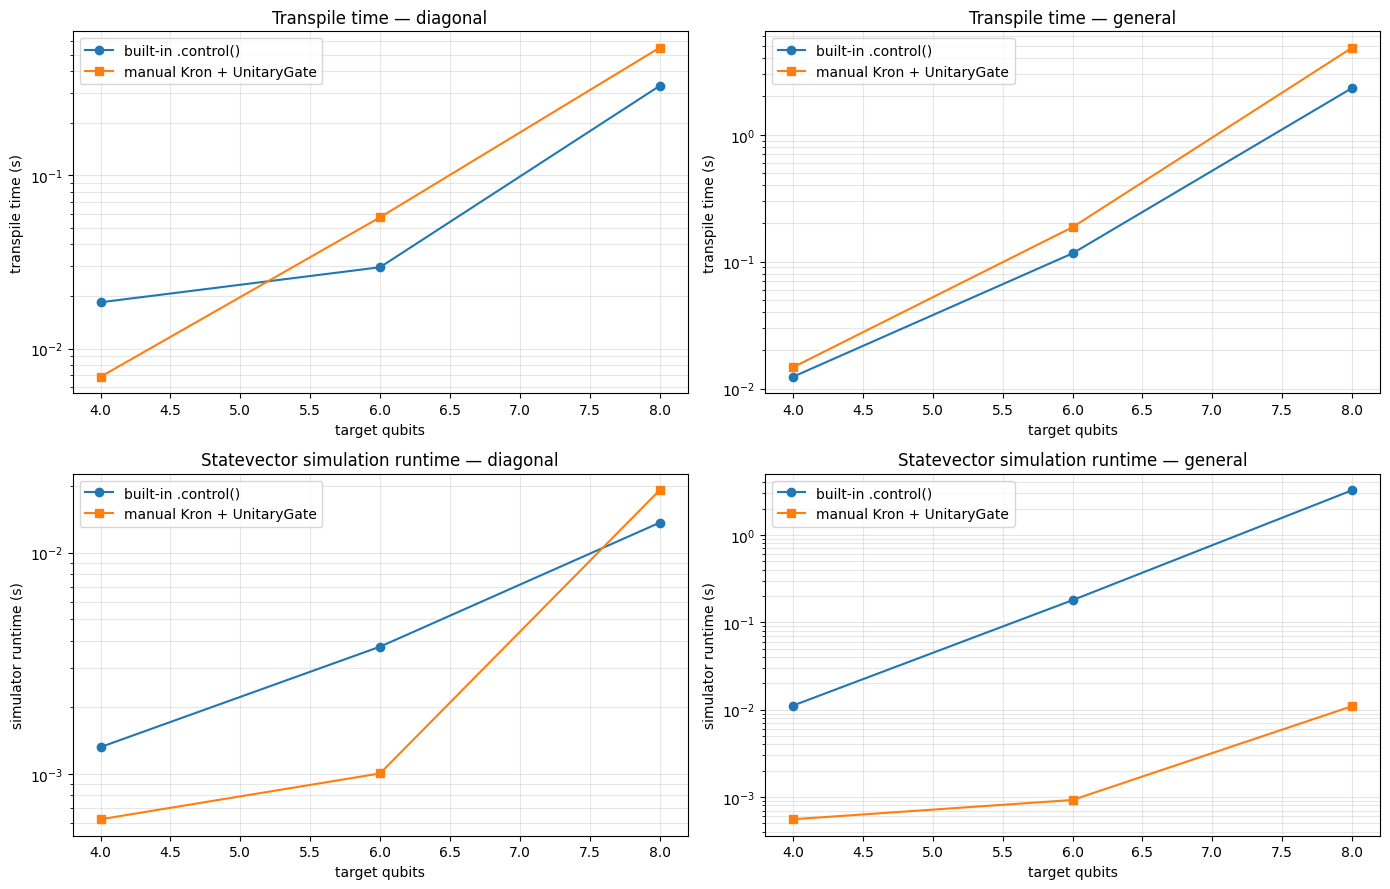

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, case in zip(axes[0], ['diagonal', 'general']):
    sub = df[df['case'] == case]
    x   = sub['n_target_qubits']
    ax.plot(x, sub['builtin_transp_s'], 'o-', label='built-in .control()')
    ax.plot(x, sub['manual_transp_s'],  's-', label='manual Kron + UnitaryGate')
    ax.set_yscale('log')
    ax.set_xlabel('target qubits')
    ax.set_ylabel('transpile time (s)')
    ax.set_title(f'Transpile time — {case}')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()

for ax, case in zip(axes[1], ['diagonal', 'general']):
    sub = df[df['case'] == case]
    x   = sub['n_target_qubits']
    ax.plot(x, sub['builtin_runtime_s'], 'o-', label='built-in .control()')
    ax.plot(x, sub['manual_runtime_s'],  's-', label='manual Kron + UnitaryGate')
    ax.set_yscale('log')
    ax.set_xlabel('target qubits')
    ax.set_ylabel('simulator runtime (s)')
    ax.set_title(f'Statevector simulation runtime — {case}')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

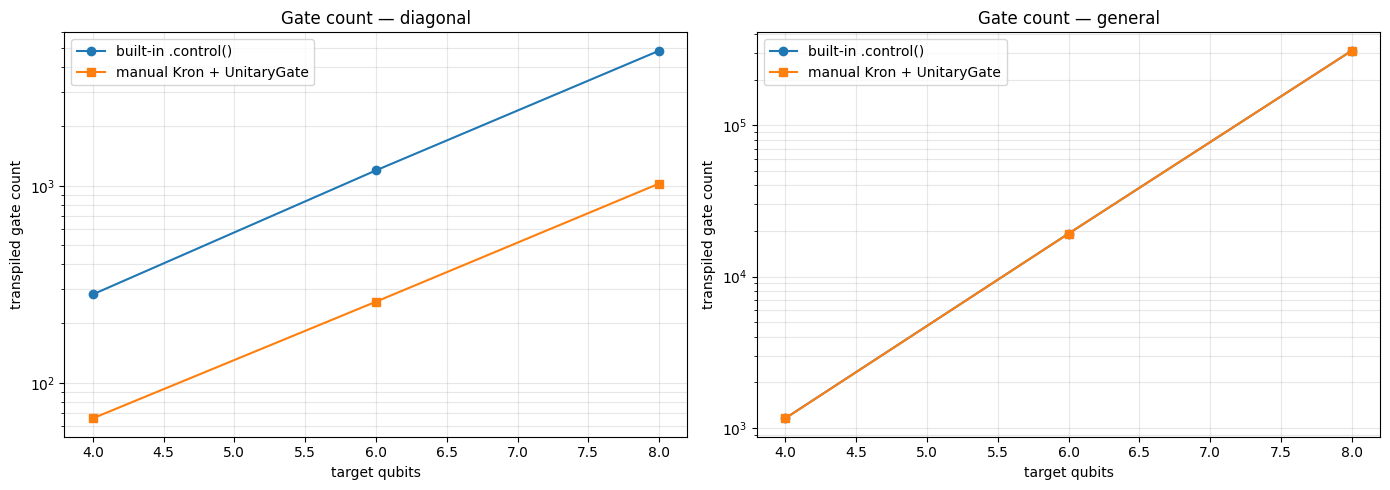

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, case in zip(axes, ['diagonal', 'general']):
    sub = df[df['case'] == case]
    x   = sub['n_target_qubits']
    ax.plot(x, sub['builtin_gates'], 'o-', label='built-in .control()')
    ax.plot(x, sub['manual_gates'],  's-', label='manual Kron + UnitaryGate')
    ax.set_yscale('log')
    ax.set_xlabel('target qubits')
    ax.set_ylabel('transpiled gate count')
    ax.set_title(f'Gate count — {case}')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()